- 使用requests调用天气API（如和风天气）

- 实现命令行参数解析（argparse）

- 格式化输出天气信息

#### request
- 是python的一个第三方库，用于发送HTTP请求
- 让python程序可以访问网上的资源
- 

#### argparse
- argparse是python自带的库，用于解析命令行参数。
- 简单理解：当用户在命令行输入 python weather.py -c 北京 -a 时，argparse 帮你解析出：

- -c 参数的值是 "北京"

- -a 参数存在（用户想要空气质量）

In [3]:
import requests
import argparse


In [12]:
# 在Jupyter单元格中

def get_weather(api_key, location, city_name=None):
    """
    天气查询函数 - 适合Jupyter使用
    """
    
    # 设置请求头
    headers = {'X-QW-Api-Key': api_key}
    
    # 发送请求
    url = "https://your_api_host.com/v7/weather/now"
    params = {'location': location}
    
    try:
        print(f"🔍 正在查询城市ID: {location}...")
        
        r = requests.get(url, headers=headers, params=params, timeout=10)
        
        if r.status_code != 200:
            print(f"❌ HTTP错误: {r.status_code}")
            return None
            
        data = r.json()
        
        if data.get('code') == '200':
            now = data['now']
            display_name = city_name if city_name else location
            
            # 美化输出
            from IPython.display import display, HTML
            display(HTML(f"""
            <div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); 
                        color: white; padding: 20px; border-radius: 10px; 
                        font-family: Arial, sans-serif; max-width: 400px;">
                <h2 style="margin-top: 0;">🌤️ {display_name} 天气</h2>
                <p style="font-size: 14px; opacity: 0.9;">更新时间: {data.get('updateTime', '未知')}</p>
                <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 10px;">
                    <div>📊 天气: {now.get('text', '未知')}</div>
                    <div>🌡️ 温度: {now.get('temp', 'N/A')}°C</div>
                    <div>🤔 体感: {now.get('feelsLike', 'N/A')}°C</div>
                    <div>💧 湿度: {now.get('humidity', 'N/A')}%</div>
                    <div>💨 风向: {now.get('windDir', '未知')}</div>
                    <div>🌪️ 风速: {now.get('windSpeed', 'N/A')} km/h</div>
                    <div>📈 气压: {now.get('pressure', 'N/A')} hPa</div>
                    <div>👁️ 能见度: {now.get('vis', 'N/A')} km</div>
                </div>
            </div>
            """))
            
            return data
        else:
            print(f"❌ 错误: {data.get('code')}")
            return None
            
    except Exception as e:
        print(f"❌ 出错: {e}")
        return None

# 使用示例
api_key = "your_api"  # 替换为你的API密钥
get_weather(api_key, "101010100", "北京")

🔍 正在查询城市ID: 101010100...


{'code': '200',
 'updateTime': '2026-02-17T23:26+08:00',
 'fxLink': 'https://www.qweather.com/weather/beijing-101010100.html',
 'now': {'obsTime': '2026-02-17T23:25+08:00',
  'temp': '4',
  'feelsLike': '0',
  'icon': '150',
  'text': '晴',
  'wind360': '308',
  'windDir': '西北风',
  'windScale': '2',
  'windSpeed': '10',
  'humidity': '19',
  'precip': '0.0',
  'pressure': '1018',
  'vis': '19',
  'cloud': '0',
  'dew': '-20'},
 'refer': {'sources': ['QWeather'],
  'license': ['QWeather Developers License']}}

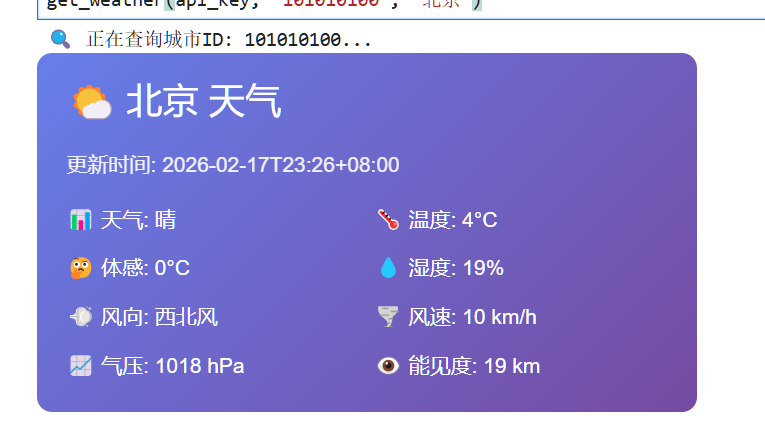